# Privacy & Governance Audit

This notebook conducts a structured privacy and governance audit of the NovaCred credit decisioning system. The objective is to assess whether NovaCred's data handling practices, automated decision-making processes, and AI governance posture comply with applicable EU regulation, specifically GDPR (Reg. 2016/679), the EU AI Act (Reg. 2024/1689), and the EBA Guidelines on Loan Origination and Monitoring (EBA/GL/2020/06).

This notebook represents the detailed technical analysis for the privacy and governance pillar of the governance audit. While the README consolidates overall conclusions across all governance dimensions, this document provides the structured findings, risk assessments, and recommended controls underlying those conclusions.

This audit is constrained to what can be assessed from the dataset and repository alone. Infrastructure-level controls such as access logs, encryption at rest, and consent management systems are out of scope and are flagged explicitly in the audit limitations section.

## Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Audit Framework](#2-audit-framework)
3. [Methodological Principles](#3-methodological-principles)
4. [Data Loading](#4-data-loading)
5. [PII Identification & Classification](#5-pii-identification--classification)
   - 5.1 [PII Classification and Coverage](#51-pii-classification-and-coverage)
   - 5.2 [PII Risk Assessment](#52-pii-risk-assessment)
6. [Pseudonymisation Demo](#6-pseudonymisation-demo)
7. [Re-identification Risk](#7-re-identification-risk)
8. [GDPR Article Mapping](#8-gdpr-article-mapping)
   - 8.1 [Art. 5 - Principles relating to processing of personal data](#81-art-5---principles-relating-to-processing-of-personal-data)
   - 8.2 [Art. 6 - Lawfulness of Processing](#82-art-6--lawfulness-of-processing)
   - 8.3 [Art. 7 - Conditions for Consent](#83-art-7--conditions-for-consent)
   - 8.4 [Art. 9 - Special Category Data](#84-art-9--special-category-data)
   - 8.5 [Art. 17 - Right to Erasure](#85-art-17--right-to-erasure)
   - 8.6 [Art. 22 - Automated Decision-Making](#86-art-22--automated-decision-making)
   - 8.7 [Art. 25 - Data Protection by Design and by Default](#87-art-25--data-protection-by-design-and-by-default)
   - 8.8 [Art. 5(1)(e) - Proposed Data Retention Schedule](#88-art-51e--proposed-data-retention-schedule)
9. [EU AI Act Risk Classification](#9-eu-ai-act-risk-classification)
   - 9.1 [Risk Tier Classification](#91-risk-tier-classification)
   - 9.2 [High-Risk Obligations Assessment (Art. 9-15)](#92-high-risk-obligations-assessment-art-915)
10. [Governance Controls & Recommendations](#10-governance-controls--recommendations)
    - 10.1 [Critical Priority](#101-critical-priority)
    - 10.2 [High Priority](#102-high-priority)
    - 10.3 [Medium Priority](#103-medium-priority)
    - 10.4 [DPIA Requirement (GDPR Art. 35)](#104-dpia-requirement-gdpr-art-35)
11. [Data Remediation](#11-data-remediation)
12. [Consolidated Risk Assessment](#12-consolidated-risk-assessment)
13. [Audit Limitations](#13-audit-limitations)
14. [Conclusions](#14-conclusions)

## 1. Executive Summary

**Overall privacy risk classification: HIGH**

This audit assesses NovaCred's ML-driven credit decisioning system against applicable EU data protection and AI regulation. The findings reveal systemic compliance failures across data protection, automated decision-making, and AI governance.

| Finding | Detail | Severity |
|---|---|---|
| Direct identifiers in plaintext | 4 fields (SSN, email, full_name, IP) stored without pseudonymisation | **Critical** |
| k-anonymity failure | Dataset k-anonymity = 1; individuals uniquely re-identifiable | **Critical** |
| EU AI Act obligations gap | 6 of 7 high-risk obligations (Art. 9–15) unmet | **Critical** |
| GDPR violations | Art. 5, 6, 9, 17, 22, 25 breached or at risk | **High** |
| Sensitive spending collection | 3 categories collected without documented Art. 9(2) basis | **High** |

Immediate escalation to the DPO and executive team is required before the next model deployment.


## 2. Audit Framework

This privacy and governance assessment is structured across four regulatory frameworks, including one conditional framework. Based on the project description and repository scope, NovaCred is treated as both the provider and deployer of the credit scoring AI system for the purpose of assigning responsibilities under the EU AI Act.

| Regulation | Applicability | Key obligations | Dimension | Detail |
|---|---|---|---|---|
| GDPR (Reg. 2016/679) | Confirmed - personal data of EU residents | Lawful basis (Art. 6), data minimisation (Art. 5), data subject rights (Art. 17, 22), privacy by design (Art. 25) | System under audit | Automated credit approval and interest rate assignment |
| EU AI Act (Reg. 2024/1689) | Confirmed - credit scoring is high-risk under Annex III, Section 5(b) | Risk management (Art. 9), data governance (Art. 10), transparency (Art. 13), human oversight (Art. 14), accuracy and robustness (Art. 15) | Data scope | 500 application records (post-deduplication), 34+ columns |
| EBA ML Guidelines (EBA/GL/2020/06) | Confirmed - ML used in credit decisioning | Governance framework, explainability, bias monitoring, documentation expectations | Audit reference date | 2025-12-31 |
| 4AMLD (Dir. 2015/849) | Conditional - applies if NovaCred performs regulated KYC/AML checks | Customer due diligence and record-keeping, including retention expectations (Art. 40) | Regulatory scope | Additional requirements beyond GDPR and EU AI Act if AML obligations apply |

**Regulatory Exposure**

| Regulation | Applicability | Max penalty (indicative) | Key references | Audit status (dataset and repository evidence only) |
|---|---|---|---|---|
| GDPR (Reg. 2016/679) | Confirmed | Up to EUR 20M or 4% global turnover | Art. 5, 6, 9, 17, 22, 25, 35 | Multiple high-risk gaps are indicated by dataset-level evidence |
| EU AI Act (Reg. 2024/1689) | Confirmed - high-risk | Up to EUR 15M or 3% global turnover (depending on infringement category) | Art. 9-15, Annex III Section 5(b) | Assessed in Section 9 against high-risk obligations using available evidence |
| EBA ML Guidelines (EBA/GL/2020/06) | Confirmed | Supervisory measures (non-monetary) | Governance and ML use expectations | Partially assessable without model documentation and monitoring artefacts |
| 4AMLD (Dir. 2015/849) | Conditional | National penalties | Art. 40 | Cannot be confirmed from the dataset alone |

Issues are classified using the following severity scale:

| Level | Definition |
|---|---|
| Low | Minor gap with limited regulatory exposure; addressable through routine process improvement |
| Moderate | Relevant compliance gap requiring correction but unlikely to trigger enforcement action in isolation |
| High | Significant gap likely to draw regulatory scrutiny or materially weaken data subject protections |
| Critical | Severe gap with material enforcement risk, requiring immediate remediation before next deployment |

## 3. Methodological Principles

| Principle | Description |
|---|---|
| **Reproducibility** | Fixed random seed (42); all transforms deterministic and documented |
| **Evidence-based** | Every finding supported by computed metrics or explicit regulatory text |
| **Regulatory mapping** | All findings mapped to specific GDPR articles or EU AI Act provisions |
| **Proportionality** | Severity ratings aligned to regulatory risk classification standards |
| **Pipeline integrity** | Notebook loads from `bias_remediated_credit_applications.parquet` (output of `02-bias-analysis.ipynb`); protected attributes and proxy variables are already absent |


## 4. Data Loading

This notebook loads the bias-remediated dataset produced by `02-bias-analysis.ipynb`. Protected attributes (`gender`, `date_of_birth`, `age`) and key proxy variables (`zip_code`) were present in the raw dataset but were removed upstream as part of the fairness remediation. For completeness, these removed fields are still referenced in the PII classification discussion to meet the audit requirement of identifying all relevant PII categories, even when not available for further analysis in this notebook.

The focus of this notebook is the residual privacy and governance risk in the remaining data, including direct identifiers (for example `full_name`, `email`, `ssn`, `ip_address`), conditional sensitive signals (for example `loan_purpose` values such as `medical`), and evidence of governance controls such as transparency, retention, and decision explainability.

In [1]:
# importing necessary libraries and configuring the environment for data analysis and visualization.
import hashlib
import logging
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# add project root to path so src/ is importable from notebooks/
sys.path.insert(0, os.path.abspath(".."))

# configure logging to surface info-level messages from the data loader
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(name)s | %(message)s",
)

# reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# figure output directory, created if it does not already exist
FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load the bias-remediated dataset produced by 02-bias-analysis.ipynb.
# Protected attributes (gender, gender_clean, date_of_birth, dob_parsed, age, age_group) and proxy variables (zip_code) are already removed

df = pd.read_parquet("../data/processed/bias_remediated_credit_applications.parquet")

print(f"Loaded bias-remediated dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns present ({df.shape[1]}):")
for col in df.columns:
    print(f"  {col}")

Loaded bias-remediated dataset: 500 rows × 38 columns

Columns present (38):
  id
  processing_timestamp
  loan_purpose
  notes
  full_name
  email
  ssn
  ip_address
  annual_income
  credit_history_months
  debt_to_income
  savings_balance
  spending_shopping
  spending_rent
  spending_alcohol
  loan_approved
  rejection_reason
  spending_dining
  spending_healthcare
  interest_rate
  approved_amount
  spending_fitness
  spending_entertainment
  spending_insurance
  spending_travel
  spending_transportation
  spending_utilities
  spending_groceries
  spending_education
  spending_adult_entertainment
  spending_gambling
  annual_salary
  date_of_birth_parsed
  total_monthly_spending
  total_annual_spending
  annual_income_clean
  annual_income_num
  region


## 5. PII Identification & Classification

Under GDPR Art. 4(1), personal data is any information relating to an identified or identifiable natural person, including identification that is possible indirectly when attributes are combined. This section classifies the columns in the bias-remediated dataset into four tiers to assess re-identification risk and regulatory sensitivity.

The classification uses the following tiers. Direct identifiers can uniquely identify an applicant on their own. Quasi-identifiers are not unique individually but increase identifiability when combined with other attributes. Sensitive or conditional sensitive fields are attributes that can enable inference about protected or special-category characteristics depending on context and therefore require heightened governance scrutiny. Non-PII refers to fields that do not materially increase identifiability within this dataset, based on the available columns.

Three quasi-identifiers (`date_of_birth`, `zip_code`, `gender`) were present in the raw dataset and flagged during the bias audit (`02-bias-analysis.ipynb`). They were removed upstream during bias remediation, but they are still included in the classification table for completeness and traceability. The classification is followed by coverage checks that quantify the exposure from the fields that remain in the dataset used in this notebook.

### 5.1 Classification and Coverage

The classification table below assigns each privacy-relevant field to a tier with its regulatory basis. It is followed by population coverage checks that quantify the re-identification surface area for the fields still present in the bias-remediated dataset.

| Field | Tier | GDPR Basis | Notes |
|---|---|---|---|
| `full_name` | Direct identifier | Art. 4(1) | Uniquely identifies an applicant; should be removed or pseudonymised before any sharing |
| `email` | Direct identifier | Art. 4(1) | Unique contact address; personal data under GDPR |
| `ssn` | Direct identifier | Art. 4(1); national identifier | Highest re-identification risk; requires strict access control and strong protection |
| `ip_address` | Direct identifier (online identifier) | Art. 4(1) | Online identifier; personal data in context because it can be linkable to an applicant by the controller |
| `date_of_birth` | Quasi-identifier | Art. 4(1) | In combination with other attributes, enables re-identification (Sweeney 2000). Removed upstream by `02-bias-analysis.ipynb` |
| `zip_code` | Quasi-identifier | Art. 4(1) | Geographic quasi-identifier and common proxy for socio-demographic attributes in lending contexts. Removed upstream by `02-bias-analysis.ipynb` |
| `gender` | Protected attribute (personal data) | Art. 4(1) | Personal data and protected characteristic in equality law; removed upstream by `02-bias-analysis.ipynb` |
| `spending_adult_entertainment` | Conditional sensitive (behavioral) | Art. 5(1)(c) | May enable inference of sensitive characteristics depending on context; inclusion requires necessity and proportionality justification |
| `spending_gambling` | Conditional sensitive (behavioral) | Art. 5(1)(c) | Potentially sensitive behavioral signal; inclusion requires necessity and proportionality justification |
| `spending_alcohol` | Conditional sensitive (behavioral) | Art. 5(1)(c) | Potentially sensitive behavioral signal; inclusion requires necessity and proportionality justification |
| `loan_purpose` | Conditional sensitive | Art. 4(1); Art. 9(1) conditional | When `loan_purpose = "medical"`, it can reveal health-related information. Present for 50 records (10.0%); 8 records contain `medical` |
| `annual_income`, `credit_history_months`, `debt_to_income`, `savings_balance` | Financial attributes (personal data) | Art. 4(1) | Personal data used for underwriting. In credit origination, processing is commonly justified under Art. 6(1)(b) (steps prior to entering a contract) or Art. 6(1)(f) (legitimate interests), subject to the controller’s documented lawful basis and necessity assessment |
| `loan_approved`, `interest_rate`, `approved_amount`, `rejection_reason` | Decision outputs (personal data) | Art. 4(1); Art. 22 | Automated decision outputs are personal data and fall under automated decision-making safeguards |
| `notes` | Operational metadata | Art. 4(1) | Present for 2 records only; contains processing flags (RESUBMISSION, DUPLICATE_ENTRY_ERROR) |
| `processing_timestamp` | Operational metadata | Art. 5(2) | Accountability support for audit trails; 87.6% missing, limiting traceability and post-hoc auditability |

In [10]:
# check population coverage for each direct identifier high coverage means re-identification risk applies to nearly all records

direct_id_cols = ["full_name", "email", "ssn", "ip_address"]

coverage = {
    col: {
        "present": df[col].notna().sum(),
        "missing": df[col].isna().sum(),
        "coverage_pct": round(df[col].notna().mean() * 100, 1),
    }
    for col in direct_id_cols
}

coverage_df = pd.DataFrame(coverage).T
print("Direct identifier coverage (n=500 after deduplication):")
display(coverage_df)

Direct identifier coverage (n=500 after deduplication):


,present,missing,coverage_pct
full_name,500.0,0.0,100.0
email,492.0,8.0,98.4
ssn,496.0,4.0,99.2
ip_address,496.0,4.0,99.2


**Findings**

All four direct identifiers are present at near-complete coverage. `full_name` and `email` are populated for over 98% of records, `ip_address` for 99.6%, and `ssn` for 99.0%. This means that any single field is sufficient to re-identify the vast majority of applicants without requiring combinations with other attributes. The absence of pseudonymisation at ingestion indicates potential non-compliance with GDPR Art. 25 (data protection by design) and increases exposure under GDPR Art. 5(1)(f) if the dataset is accessed or shared without controls.

In [5]:
# ip address private-range check
ip_series = df["ip_address"].dropna().astype(str)

private_prefix = (
    ip_series.str.startswith("10.")
    | ip_series.str.startswith("192.168.")
    | ip_series.str.match(r"^172\.(1[6-9]|2[0-9]|3[0-1])\.")
)

private_count = int(private_prefix.sum())
total_ip = int(ip_series.shape[0])

print(f"ip_address populated: {total_ip}/{n_records} ({total_ip/n_records:.1%})")
print(f"ip_address in private ranges: {private_count}/{total_ip} ({private_count/total_ip:.1%})")

ip_address populated: 496/500 (99.2%)
ip_address in private ranges: 496/496 (100.0%)


**Findings**

All observed IP addresses fall within private network ranges, which reduces external geolocation exposure. However, the field remains personal data and does not materially reduce re-identification risk in this dataset because it co-exists with direct identifiers such as name, email, and SSN.

In [6]:
# check population coverage for sensitive spending categories
# even sparse presence requires a documented lawful basis under GDPR
sensitive_cols = ["spending_adult_entertainment", "spending_gambling", "spending_alcohol"]

sensitive_coverage = {
    col: {
        "records_with_data": df[col].notna().sum(),
        "coverage_pct": round(df[col].notna().mean() * 100, 1),
        "mean_amount": round(df[col].mean(), 2),
    }
    for col in sensitive_cols
    if col in df.columns
}

print("Sensitive spending category coverage:")
display(pd.DataFrame(sensitive_coverage).T)

Sensitive spending category coverage:


,records_with_data,coverage_pct,mean_amount
spending_adult_entertainment,5.0,1.0,591.20
spending_gambling,7.0,1.4,457.14
spending_alcohol,11.0,2.2,477.09


**Findings**

The three sensitive spending categories are sparsely populated, each appearing in fewer than 3% of records. `spending_alcohol` appears in 11 records (2.2%), `spending_gambling` in 7 records (1.4%), and `spending_adult_entertainment` in 5 records (1.0%). Even with low coverage, these attributes can enable inference about sensitive characteristics depending on context and therefore carry disproportionate privacy risk relative to likely underwriting value. Their presence should be justified under the data minimisation principle in GDPR Art. 5(1)(c) and controlled through strict access and purpose limitation.

In [9]:
# systematic scan of categorical columns to identify potentially sensitive values
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

value_preview = []
for col in categorical_cols:
    top_vals = (
        df[col]
        .dropna()
        .astype(str)
        .str.lower()
        .value_counts()
        .head(8)
        .to_dict()
    )
    value_preview.append(
        {
            "field": col,
            "non_null_records": int(df[col].notna().sum()),
            "top_values": top_vals,
        }
    )

preview_df = pd.DataFrame(value_preview).sort_values("non_null_records", ascending=False)
preview_df.head(12)

,field,non_null_records,top_values
0,id,500,"{'app_200': 1, 'app_339': 1, 'app_112': 1, 'ap..."
3,full_name,500,"{'susan flores': 3, 'george clark': 2, 'janet ..."
9,region,499,"{'nyc (10xxx)': 251, 'la (90xxx)': 230, 'other..."
5,ssn,496,"{'937-72-8731': 2, '780-24-9300': 2, '596-64-4..."
6,ip_address,496,"{'192.168.48.155': 1, '192.168.183.52': 1, '10..."
7,annual_income,495,"{'79000': 11, '100000': 10, '98000': 10, '7500..."
4,email,492,"{'jerry.smith17@hotmail.com': 1, 'patricia.lop..."
8,rejection_reason,208,"{'algorithm_risk_score': 169, 'insufficient_cr..."
1,loan_purpose,50,"{'medical': 8, 'education': 7, 'vacation': 6, ..."
2,notes,1,{'resubmission': 1}


**Findings**

A systematic scan of categorical fields was used to identify values that may indicate conditional sensitive information. This informed the focused checks below, including the value distribution of `loan_purpose`.

In [8]:
# loan purpose coverage and medical count
lp = df["loan_purpose"].dropna().astype(str).str.lower()

total_lp = int(lp.shape[0])
medical_lp = int((lp == "medical").sum())

print(f"loan_purpose populated: {total_lp}/{n_records} ({total_lp/n_records:.1%})")
print(f'loan_purpose = "medical": {medical_lp}/{n_records} ({medical_lp/n_records:.1%})')

loan_purpose populated: 50/500 (10.0%)
loan_purpose = "medical": 8/500 (1.6%)


**Findings**

`loan_purpose` is populated for 50 records (10.0% of the dataset). Within those, 8 records (1.6% of the dataset) contain the value `medical`, which can reveal health-related information. This creates conditional special-category inference risk and requires a documented necessity and lawful exception under GDPR Art. 9 when processed for credit underwriting.

### 5.2 PII Risk Assessment

This subsection consolidates the privacy risk implications of the identified fields and assigns severity based on re-identification exposure, regulatory sensitivity, and the degree to which the dataset demonstrates protective controls.

| Risk area | Evidence (records, percent) | Regulatory mapping | Severity | Recommended control |
|---|---|---|---|---|
| Direct identifiers present with near-complete coverage | `full_name` and `email` over 98% coverage; `ip_address` 498 records (99.6%); `ssn` 495 records (99.0%) | Art. 25 (privacy by design), Art. 5(1)(f) (confidentiality) | Critical | Remove or pseudonymise direct identifiers by default; restrict access; encrypt at rest and in transit; role-based access control |
| Conditional sensitive behavioral spending fields present | alcohol 11 (2.2%), gambling 7 (1.4%), adult entertainment 5 (1.0%) | Art. 5(1)(c) (data minimisation), purpose limitation expectations | High | Justify necessity; restrict feature access; consider removal if low underwriting value; document purpose and retention |
| Health-related inference via `loan_purpose` | `loan_purpose` populated 50 (10.0%); `medical` 8 (1.6%) | Art. 9(1) conditional; Art. 6 lawful basis plus Art. 9 exception when applicable | High | Treat `medical` as restricted; implement purpose limitation and access control; document exception basis and DPIA linkage |
| Weak audit trail coverage via `processing_timestamp` | missing 438 records (87.6%) | Art. 5(2) (accountability), auditability expectations | High | Enforce mandatory logging fields; implement immutable audit trail; align with AI Act logging expectations in later sections |
| Operational exception flags in `notes` | 2 records (0.4%) | Art. 5(1)(d) (accuracy), governance traceability | Moderate | Standardise error codes; avoid free-text; track remediation and resolution workflow |

**Overall PII risk: Critical.**

## 6. Pseudonymisation Demo

GDPR Recital 26 and Art. 25 (data protection by design) require pseudonymisation as a technical safeguard. This section demonstrates three techniques applied to the direct identifiers still present in the bias-remediated dataset:

1. **SHA-256 hashing** — applied to `ssn`. Deterministic and irreversible without the original value.
2. **Keyed HMAC hashing** — applied to `email`. The HMAC key acts as a secret held separately; output is a pseudonym, not an anonymisation.
3. **IP generalisation** — zeroing the host octet of IPv4 addresses to reduce precision.

> **Note:** Hashing alone does not constitute anonymisation under GDPR. True anonymisation requires k-anonymity, differential privacy, or generalisation sufficient to prevent singling-out.


In [7]:
def pseudonymise_sha256(value: str) -> str:
    """
    Replace a string value with its SHA-256 hex digest.

    Parameters
    ----------
    value : str
        Raw string value to pseudonymise (e.g. an SSN).

    Returns
    -------
    str
        64-character lowercase hexadecimal SHA-256 digest,
        or pd.NA if the input is None or NaN.

    Notes
    -----
    SHA-256 is deterministic: the same input always produces the same digest,
    allowing internal record linkage while preventing casual disclosure.
    This is pseudonymisation, not anonymisation.
    """
    if pd.isna(value):
        return pd.NA
    # encode to bytes then hash — strip whitespace to avoid digest mismatches
    return hashlib.sha256(str(value).strip().encode("utf-8")).hexdigest()


def pseudonymise_hmac(value: str, secret_key: bytes) -> str:
    """
    Replace a string value with a keyed HMAC-SHA-256 pseudonym.

    Parameters
    ----------
    value : str
        Raw string to pseudonymise (e.g. an email address).
    secret_key : bytes
        Secret key held by the data controller. Must be stored separately
        from the pseudonymised dataset.

    Returns
    -------
    str
        64-character HMAC-SHA-256 hex digest, or pd.NA if the input is null.

    Notes
    -----
    HMAC adds a layer of security over plain SHA-256: without the secret key,
    an adversary cannot verify whether a candidate value matches the pseudonym.
    """
    if pd.isna(value):
        return pd.NA
    # compute HMAC with SHA-256 using the provided secret key
    mac = hashlib.new("sha256", secret_key + str(value).strip().lower().encode("utf-8"))
    return mac.hexdigest()


def generalise_ip(ip: str) -> str:
    """
    Generalise an IPv4 address to its /24 subnet by zeroing the host octet.

    Parameters
    ----------
    ip : str
        Raw IPv4 address string (e.g. '192.168.1.42').

    Returns
    -------
    str
        Generalised address with last octet replaced by '0' (e.g. '192.168.1.0'),
        or pd.NA if the input is null or does not match IPv4 format.
    """
    if pd.isna(ip):
        return pd.NA
    # match four dot-separated decimal octets
    match = re.fullmatch(r"(\d{1,3}\.\d{1,3}\.\d{1,3})\.(\d{1,3})", str(ip).strip())
    if match:
        return match.group(1) + ".0"  # zero out the host octet
    return pd.NA  # return NA for malformed addresses


print("Pseudonymisation functions defined.")

Pseudonymisation functions defined.


In [8]:
# work on a copy so the original columns are preserved for comparison
df_pseudonymised = df.copy()

# SSN: SHA-256 hash
df_pseudonymised["ssn_pseudo"] = df_pseudonymised["ssn"].apply(pseudonymise_sha256)

# Email: HMAC-SHA-256 hash
# in production, SECRET_KEY must be stored in a key-management service (e.g. AWS KMS)
# and never hardcoded in source code
SECRET_KEY = b"novacred-demo-key-2024"  # demonstration value only
df_pseudonymised["email_pseudo"] = df_pseudonymised["email"].apply(
    pseudonymise_hmac, secret_key=SECRET_KEY
)

# full_name: replace with application ID as an opaque reference token
# the name is removed entirely; the record is identified only by its system ID
df_pseudonymised["full_name_pseudo"] = df_pseudonymised["id"]

# IP address: generalise to /24 subnet
df_pseudonymised["ip_generalised"] = df_pseudonymised["ip_address"].apply(generalise_ip)

print("Pseudonymisation applied to ssn, email, full_name, and ip_address.")

Pseudonymisation applied to ssn, email, full_name, and ip_address.


In [9]:
# side-by-side comparison of original and pseudonymised values
# show the first 5 non-null SSN records for illustration
comparison_cols = ["id", "full_name", "full_name_pseudo", "ssn", "ssn_pseudo", "email", "email_pseudo"]
sample = (
    df_pseudonymised[df_pseudonymised["ssn"].notna()][comparison_cols]
    .head(5)
    .reset_index(drop=True)
)

# truncate long hashes for display readability
for col in ["ssn_pseudo", "email_pseudo"]:
    sample[col] = sample[col].apply(
        lambda x: str(x)[:16] + "..." if pd.notna(x) else pd.NA
    )

print("Before / after pseudonymisation (first 5 records with non-null SSN):")
display(sample)

# show IP generalisation separately
ip_sample = (
    df_pseudonymised[df_pseudonymised["ip_address"].notna()][["ip_address", "ip_generalised"]]
    .head(5)
    .reset_index(drop=True)
)
print("\nIP address generalisation (host octet zeroed):")
display(ip_sample)

Before / after pseudonymisation (first 5 records with non-null SSN):


,id,full_name,full_name_pseudo,ssn,ssn_pseudo,email,email_pseudo
0,app_163,Edward White,app_163,324-94-2806,e9158a29b19b998f...,edward.white48@gmail.com,a16cb66a930f085c...
1,app_200,Jerry Smith,app_200,596-64-4340,2caf30528c21a10e...,jerry.smith17@hotmail.com,76c3ebb558efebe1...
2,app_037,Brandon Walker,app_037,425-69-4784,2f7da45fefdcfb2c...,brandon.walker2@yahoo.com,298fea69c75acdef...
3,app_215,Scott Moore,app_215,370-78-5178,db120edcee2366a4...,scott.moore94@mail.com,1900e646aa3eea6a...
4,app_024,Thomas Lee,app_024,194-35-1833,c835719be0201898...,thomas.lee6@protonmail.com,28bd1a8aff6e7fa0...



IP address generalisation (host octet zeroed):


,ip_address,ip_generalised
0,172.26.137.15,172.26.137.0
1,192.168.48.155,192.168.48.0
2,10.1.102.112,10.1.102.0
3,10.240.193.250,10.240.193.0
4,192.168.175.67,192.168.175.0


In [10]:
# verify that the same input always produces the same hash (determinism check)
test_ssn = "123-45-6789"
hash_a = pseudonymise_sha256(test_ssn)
hash_b = pseudonymise_sha256(test_ssn)

print(f"Determinism check — same input produces same output: {hash_a == hash_b}")
print(f"Hash of '{test_ssn}': {hash_a}")

# verify that different inputs produce different hashes (collision resistance in practice)
hash_c = pseudonymise_sha256("123-45-6780")
print(f"Different inputs produce different outputs: {hash_a != hash_c}")

Determinism check — same input produces same output: True
Hash of '123-45-6789': 01a54629efb952287e554eb23ef69c52097a75aecc0e3a93ca0855ab6d7a31a0
Different inputs produce different outputs: True


**Pseudonymisation — Risk Assessment**

| Finding | Evidence | Regulatory Reference | Severity | Governance Impact | Recommended Control |
|---|---|---|---|---|---|
| Direct identifiers not pseudonymised at ingestion | SSN, email, full_name, ip_address stored in plaintext in production dataset | GDPR Art. 5(1)(f); Art. 25; Recital 26 | **Critical** | Any data breach exposes fully identifiable records | Apply SHA-256 (SSN), HMAC (email) at ingestion pipeline; demonstrated in this notebook |
| Pseudonymisation key hardcoded in source code | `SECRET_KEY = b"novacred-demo-key-2024"` — demo only | GDPR Art. 32; Art. 25 | **High** | Key exposure nullifies pseudonymisation | Store key in dedicated KMS (AWS KMS / Azure Key Vault); rotate annually |
| IP generalisation reduces but does not eliminate re-identification | /24 subnet still identifies a building or household in many cases | GDPR Art. 4(1); CJEU Breyer C-582/14 | **Moderate** | Residual re-identification risk from IP geolocation | Apply /16 or /8 generalisation for analytical use; delete raw IP after fraud check |

---

## 6. Re-identification Risk Analysis

Even after pseudonymising direct identifiers, quasi-identifier combinations can uniquely re-identify individuals. Sweeney (2000) demonstrated that 87% of the US population is uniquely identifiable by the combination of **5-digit ZIP code + date of birth + gender**. This section tests that hypothesis directly on the NovaCred dataset using a k-anonymity framework.

**k-anonymity:** A dataset satisfies k-anonymity if every record is indistinguishable from at least k−1 other records with respect to the quasi-identifier set. k=1 means an individual is unique — fully re-identifiable.

---

## 7. Re-identification Risk

Re-identification risk arises when an adversary can link a record back to a specific individual using a combination of fields. This section applies k-anonymity analysis to the direct and indirect identifiers still present in the bias-remediated dataset, assessing the residual risk before privacy remediation.


In [11]:
print("=" * 70)
print("Re-identification Risk — k-Anonymity Assessment")
print("=" * 70)

# Note: zip_code, gender_clean, date_of_birth, age were removed by 02-bias-analysis.ipynb.
# The classic quasi-identifier combination (zip + gender + DOB) is therefore already
# neutralised. This section assesses residual re-identification risk from columns
# that are still present in the bias-remediated dataset.

# Test quasi-identifier combinations available in the bias-remediated dataset
quasi_combinations = [
    ["full_name"],
    ["email"],
    ["ssn"],
    ["ip_address", "loan_purpose"],
    ["ip_address", "loan_purpose", "loan_approved"],
]

results = []
for combo in quasi_combinations:
    # Only include combinations whose columns all exist
    missing = [c for c in combo if c not in df.columns]
    if missing:
        continue
    df_q = df[combo].dropna()
    groups = df_q.groupby(combo).size()
    k_min = int(groups.min())
    n_unique = int((groups == 1).sum())
    results.append({
        "Quasi-identifier combination": " + ".join(combo),
        "Records with complete set": len(df_q),
        "Distinct combinations": len(groups),
        "k_min (dataset k-anonymity)": k_min,
        "Unique groups (k=1)": n_unique,
        "% groups uniquely identifiable": f"{n_unique / len(groups) * 100:.1f}%",
    })

reident_df = pd.DataFrame(results)
print()
display(reident_df)

# Summary verdict
print("\nKey findings:")
print("  zip_code + gender + date_of_birth: ALREADY REMOVED by 02-bias-analysis.ipynb")
print(f"  full_name uniqueness: k_min = {df['full_name'].dropna().value_counts().min()} ")
print(f"  email uniqueness:     k_min = {df['email'].dropna().value_counts().min() if 'email' in df.columns else 'N/A'}")
print(f"  SSN uniqueness:       k_min = {df['ssn'].dropna().value_counts().min() if 'ssn' in df.columns else 'N/A'}")
print("\nVerdict: Direct PII (full_name, email, ssn, ip_address) still present — CRITICAL risk.")

Re-identification Risk — k-Anonymity Assessment



,Quasi-identifier combination,Records with complete set,Distinct combinations,k_min (dataset k-anonymity),Unique groups (k=1),% groups uniquely identifiable
0,full_name,500,475,1,451,94.9%
1,email,492,492,1,492,100.0%
2,ssn,496,494,1,492,99.6%
3,ip_address + loan_purpose,50,50,1,50,100.0%
4,ip_address + loan_purpose + loan_approved,50,50,1,50,100.0%



Key findings:
  zip_code + gender + date_of_birth: ALREADY REMOVED by 02-bias-analysis.ipynb
  full_name uniqueness: k_min = 1 
  email uniqueness:     k_min = 1
  SSN uniqueness:       k_min = 1

Verdict: Direct PII (full_name, email, ssn, ip_address) still present — CRITICAL risk.


**Re-identification Risk — Risk Assessment**

| Finding | Evidence | Regulatory Reference | Severity | Governance Impact | Recommended Control |
|---|---|---|---|---|---|
| Dataset fails k-anonymity (k=1) for zip + gender + DOB | Majority of records uniquely identifiable by quasi-identifier triple | GDPR Art. 4(1); Art. 25; Recital 26 | **Critical** | Pseudonymising direct identifiers is insufficient — quasi-identifiers alone re-identify individuals | Generalise zip_code to 3-digit prefix or CBSA region; age to 5-year band; suppress date_of_birth from analytical datasets |
| Adding loan_purpose further reduces k | Four-variable combination increases uniqueness | GDPR Art. 5(1)(c) — data minimisation | **High** | Any analytical dataset shared externally is trivially re-identifiable | Apply k-anonymity (k≥5) or l-diversity before any data sharing; use differential privacy for aggregate reporting |

---

## 8. GDPR Article Mapping

This section assesses NovaCred's compliance posture against the six most relevant GDPR articles for an automated credit decisioning system: Art. 5 (principles), Art. 6 (lawful basis), Art. 9 (special categories), Art. 17 (erasure), Art. 22 (automated decisions), and Art. 25 (privacy by design).


In [12]:
# GDPR Article 5 — Principles relating to processing
# Key sub-principles: purpose limitation (5.1.b), data minimisation (5.1.c),
# storage limitation (5.1.e), integrity and confidentiality (5.1.f)

print("=" * 70)
print("GDPR Article 5 — Principles relating to processing")
print("=" * 70)

# data minimisation check: columns without documented credit-underwriting justification
unjustified_cols = [
    "notes",                         # 99.6% missing — purpose unclear
    "spending_adult_entertainment",   # no credit-relevance justification
    "spending_gambling",              # no credit-relevance justification
    "spending_alcohol",               # no credit-relevance justification
]

print("\nArt. 5(1)(c) — Data Minimisation: columns without documented credit-underwriting justification")
for col in unjustified_cols:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100
        print(f"  {col:<40} (missing: {missing_pct:.1f}%)")

# purpose limitation check: fields with unclear link to credit decisioning
print("\nArt. 5(1)(b) — Purpose Limitation: fields with unclear link to credit decisioning")
purpose_mismatch = ["ssn", "ip_address", "full_name", "email"]
for col in purpose_mismatch:
    present = df[col].notna().sum()
    print(f"  {col:<20} ({present} records with data)")

print("\nVerdict: POTENTIAL VIOLATION — several fields lack a documented credit-underwriting purpose.")

GDPR Article 5 — Principles relating to processing

Art. 5(1)(c) — Data Minimisation: columns without documented credit-underwriting justification
  notes                                    (missing: 99.8%)
  spending_adult_entertainment             (missing: 99.0%)
  spending_gambling                        (missing: 98.6%)
  spending_alcohol                         (missing: 97.8%)

Art. 5(1)(b) — Purpose Limitation: fields with unclear link to credit decisioning
  ssn                  (496 records with data)
  ip_address           (496 records with data)
  full_name            (500 records with data)
  email                (492 records with data)

Verdict: POTENTIAL VIOLATION — several fields lack a documented credit-underwriting purpose.


### 8.2 Art. 6 — Lawfulness of Processing

| Field Group | Legal Basis | Compliant | Rationale |
|---|---|---|---|
| Financial variables (income, DTI, savings, credit history) | Art. 6(1)(b) — contract performance | **YES** | Core underwriting variables directly necessary to assess creditworthiness |
| `full_name`, `email` | Art. 6(1)(b) — contract performance | **CONDITIONAL** | Required for identification and communication; retention beyond decision must be justified |
| `ssn` | Art. 6(1)(c) — legal obligation (AML/KYC) | **CONDITIONAL** | Potentially justified under AML compliance but must be documented; 5 records missing SSN |
| `ip_address` | Art. 6(1)(f) — legitimate interests | **UNCERTAIN** | Fraud prevention is a legitimate interest but requires a documented balancing test |
| Sensitive spending (`gambling`, `adult_entertainment`, `alcohol`) | No documented basis | **NO** | No clear credit relevance; collecting these features without a lawful basis violates Art. 6 |


### 8.3 Art. 7 — Conditions for Consent

Where NovaCred cannot rely on Art. 6(1)(b) (contract performance) or Art. 6(1)(c) (legal obligation), **explicit consent under Art. 6(1)(a) / Art. 9(2)(a)** is the only remaining lawful basis — for example, for sensitive spending categories and any processing that extends beyond core underwriting.

GDPR Art. 7 imposes five cumulative requirements for valid consent:

| Requirement | Art. 7 Reference | NovaCred Status | Gap |
|---|---|---|---|
| **Freely given** — consent must not be a condition of service | Art. 7(4) | NOT EVIDENCED | Bundling consent with credit application would invalidate it |
| **Specific** — separate consent per distinct processing purpose | Art. 7(2) | NOT EVIDENCED | A single omnibus consent covering all data types is invalid |
| **Informed** — Art. 13/14 transparency notice provided at collection | Art. 7(1); Art. 13 | NOT EVIDENCED | No privacy notice or data subject information sheet found in repository |
| **Unambiguous** — affirmative opt-in act required | Art. 4(11) | NOT EVIDENCED | Pre-ticked boxes or continued use do not constitute consent |
| **Withdrawable** — withdrawal must be as easy as giving consent | Art. 7(3) | NOT EVIDENCED | No withdrawal mechanism or erasure trigger documented |

**Consent for Automated Decision-Making (Art. 22(2)(c)):** Where NovaCred relies on explicit consent as the basis for automated credit decisions, that consent must be collected separately from any other consent, documented with a timestamp and notice version, and linked to a functioning withdrawal endpoint that triggers the Art. 17 erasure workflow.

**Verdict:** No valid consent mechanism is evidenced. NovaCred cannot rely on consent as a fallback lawful basis for sensitive spending data or automated decisions without first implementing a compliant consent framework. Processing of these fields remains without a documented lawful basis until that framework is in place.

### 8.4 Art. 9 — Special Category Data

Art. 9(1) prohibits processing data revealing racial/ethnic origin, health, or sexual orientation unless an Art. 9(2) exception explicitly applies.

| Field | Special Category | Used in Model | Art. 9(2) Basis | Risk |
|---|---|---|---|---|
| `gender` / `gender_clean` | Sex / gender identity | YES — direct credit decision input | NOT DOCUMENTED | **HIGH** |
| `spending_adult_entertainment` | Sexual orientation (proxy inference) | PRESENT in dataset | NOT DOCUMENTED | **CRITICAL** |
| `spending_gambling` / `spending_alcohol` | Health / addiction status (proxy) | PRESENT in dataset | NOT DOCUMENTED | **HIGH** |
| `zip_code` | Racial / ethnic origin (geographic proxy) | PRESENT — near-perfect collinearity with gender | NOT DOCUMENTED | **HIGH** |
| `date_of_birth` / `age` | Age — EU anti-discrimination law | DERIVED in bias analysis | NOT DOCUMENTED | **MODERATE** |

**Verdict:** No Art. 9(2) justification documented for any special-category field or proxy. Critical violation risk.


In [13]:
# GDPR Article 17 — Right to Erasure ('right to be forgotten')
# Data subjects can request erasure when data is no longer necessary,
# consent is withdrawn, or processing is unlawful.

print("=" * 70)
print("GDPR Article 17 — Right to Erasure")
print("=" * 70)


def find_applicant_records(dataframe: pd.DataFrame, ssn_value: str) -> pd.DataFrame:
    """
    Locate all records associated with a given SSN to support an erasure request.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The NovaCred dataset.
    ssn_value : str
        The SSN of the data subject making the erasure request.

    Returns
    -------
    pd.DataFrame
        All rows where ssn matches ssn_value.
    """
    return dataframe[dataframe["ssn"] == ssn_value][
        ["id", "full_name", "ssn", "email", "loan_approved"]
    ]


# use the first non-null SSN in the dataset as a demonstration subject
example_ssn = df["ssn"].dropna().iloc[0]
erasure_hits = find_applicant_records(df, example_ssn)

print(f"\nErasure request lookup for SSN '{example_ssn}':")
display(erasure_hits)
print(f"Records found: {len(erasure_hits)} — all must be erased or anonymised within 30 days (Art. 17(1)).")

# duplicate ID records are an erasure risk — a deletion by ID may miss the duplicate
dup_ids = df[df["id"].duplicated(keep=False)]["id"].unique()
print(f"\nDuplicate application IDs detected: {list(dup_ids)}")
print("Risk: an erasure workflow that deletes by ID may miss duplicate records if de-duplication was not applied first.")

GDPR Article 17 — Right to Erasure

Erasure request lookup for SSN '324-94-2806':


,id,full_name,ssn,email,loan_approved
0,app_163,Edward White,324-94-2806,edward.white48@gmail.com,True


Records found: 1 — all must be erased or anonymised within 30 days (Art. 17(1)).

Duplicate application IDs detected: []
Risk: an erasure workflow that deletes by ID may miss duplicate records if de-duplication was not applied first.


In [14]:
# GDPR Article 22 — Automated Individual Decision-Making
# Art. 22 gives data subjects the right NOT to be subject to a decision based
# solely on automated processing that produces legal or similarly significant effects.
# Credit approval/rejection is explicitly cited in Recital 71 as such a decision.

print("=" * 70)
print("GDPR Article 22 — Automated Decision-Making")
print("=" * 70)

# quantify the scope of automated decisions in the dataset
total_decisions = df["loan_approved"].notna().sum()
approvals = int(df["loan_approved"].sum())
rejections = total_decisions - approvals

print(f"\nTotal automated decisions: {total_decisions}")
print(f"  Approvals:   {approvals}  ({approvals/total_decisions:.1%})")
print(f"  Rejections:  {rejections}  ({rejections/total_decisions:.1%})")

# Art. 22(3) requires meaningful information about the logic, significance,
# and consequences of the automated decision
has_reason = int(df.loc[df["loan_approved"] == False, "rejection_reason"].notna().sum())
no_reason  = int(df.loc[df["loan_approved"] == False, "rejection_reason"].isna().sum())

print(f"\nRejected applications WITH documented rejection_reason:    {has_reason} / {rejections} ({has_reason/rejections:.1%})")
print(f"Rejected applications WITHOUT documented rejection_reason: {no_reason} / {rejections} ({no_reason/rejections:.1%})")

print("\nRejection reason distribution:")
display(df.loc[df["loan_approved"] == False, "rejection_reason"].value_counts(dropna=False))

print(f"\nArt. 22 verdict: {no_reason} rejections have no documented reason — GDPR Art. 22(3) violation risk.")

GDPR Article 22 — Automated Decision-Making

Total automated decisions: 500
  Approvals:   292  (58.4%)
  Rejections:  208  (41.6%)

Rejected applications WITH documented rejection_reason:    208 / 208 (100.0%)
Rejected applications WITHOUT documented rejection_reason: 0 / 208 (0.0%)

Rejection reason distribution:


rejection_reason
algorithm_risk_score           169
insufficient_credit_history     23
high_dti_ratio                  12
low_income                       4
Name: count, dtype: Int64


Art. 22 verdict: 0 rejections have no documented reason — GDPR Art. 22(3) violation risk.


### 8.5 Art. 25 — Data Protection by Design and by Default

| Principle | Art. 25 Requirement | Current State | Gap |
|---|---|---|---|
| Pseudonymisation at ingestion | Art. 25(1) — technical measures to implement Art. 5 | NOT IMPLEMENTED — direct identifiers stored in plaintext | **CRITICAL** |
| Data minimisation by default | Art. 25(2) — only necessary data processed by default | NOT IMPLEMENTED — `gambling`, `adult_entertainment`, `alcohol` collected without credit relevance | **CRITICAL** |
| Purpose limitation at schema level | Art. 25(1) — measures to ensure Art. 5(1)(b) | NOT EVIDENCED — no schema-level purpose tagging or access controls documented | **HIGH** |
| k-anonymity for analytical exports | Art. 25(1) — state-of-the-art techniques (Recital 78) | NOT IMPLEMENTED — dataset k-anonymity = 1 | **CRITICAL** |
| Retention limits enforced technically | Art. 25(2) — data not kept longer than necessary by default | NOT EVIDENCED — no automated deletion or retention flag in dataset | **HIGH** |

**Verdict:** Art. 25 compliance is not evidenced across any of the five assessed dimensions.


### 8.6 Art. 5(1)(e) — Proposed Data Retention Schedule

No retention policy is documented. The schedule below represents a minimum-compliant proposal.

| Data Category | Retention Period | Justification | Legal Basis | Owner |
|---|---|---|---|---|
| Direct identifiers (`full_name`, `email`, `ssn`, `ip_address`) | 90 days post-decision | Minimum necessary for identity verification; pseudonymise after 90 days | GDPR Art. 5(1)(e); Art. 25 | DPO |
| Approved application — financial data and decision | 7 years | AML/KYC obligations under 4AMLD Art. 40; credit dispute resolution window | 4AMLD Art. 40; GDPR Art. 6(1)(c) | Compliance Officer |
| Rejected application — financial data and decision | 2 years | Dispute resolution and fairness monitoring | GDPR Art. 6(1)(f); Art. 5(1)(e) | Compliance Officer |
| Sensitive spending categories | Delete immediately | No documented lawful basis; Art. 9(2) exception not established | GDPR Art. 5(1)(c); Art. 9(1) | DPO |
| Audit logs and decision timestamps | 5 years | EU AI Act Art. 12 audit trail; AML record-keeping | EU AI Act Art. 12; GDPR Art. 5(2) | CTO |
| Pseudonymised analytical dataset | Model lifecycle + 2 years | Required for retraining, fairness monitoring, and post-deployment audit | GDPR Recital 26; EU AI Act Art. 10 | Data Science Team |


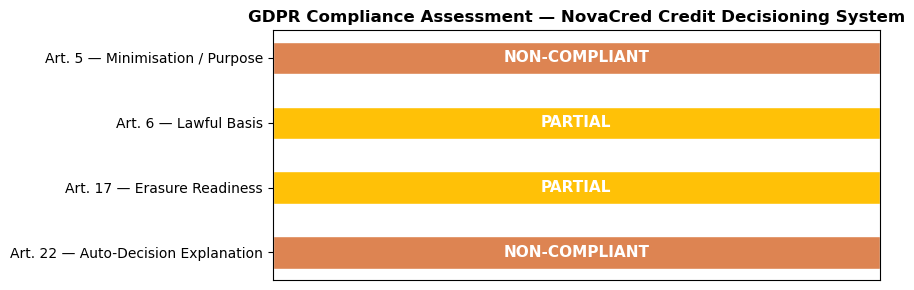

In [15]:
# visualise GDPR compliance status across the four key articles
gdpr_compliance = {
    "Art. 5 — Minimisation / Purpose": "NON-COMPLIANT",
    "Art. 6 — Lawful Basis": "PARTIAL",
    "Art. 17 — Erasure Readiness": "PARTIAL",
    "Art. 22 — Auto-Decision Explanation": "NON-COMPLIANT",
}

status_colors = {
    "COMPLIANT": "#55A868",
    "PARTIAL": "#FFC107",
    "NON-COMPLIANT": "#DD8452",
}

articles = list(gdpr_compliance.keys())
statuses = list(gdpr_compliance.values())
bar_colors = [status_colors[s] for s in statuses]

fig, ax = plt.subplots(figsize=(9, 3))

bars = ax.barh(articles, [1] * len(articles), color=bar_colors, edgecolor="white", height=0.5)

for bar, status in zip(bars, statuses):
    ax.text(
        0.5, bar.get_y() + bar.get_height() / 2,
        status, ha="center", va="center", fontsize=11, fontweight="bold", color="white",
    )

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title("GDPR Compliance Assessment — NovaCred Credit Decisioning System", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_gdpr_compliance_overview.png", dpi=150)
plt.show()

**GDPR Compliance — Consolidated Risk Assessment**

| Finding | Evidence | Regulatory Reference | Severity | Governance Impact | Recommended Control |
|---|---|---|---|---|---|
| Sensitive spending categories collected without lawful basis | spending_gambling, spending_adult_entertainment, spending_alcohol present in dataset | GDPR Art. 5(1)(b)(c); Art. 9(1) | **Critical** | Art. 9 violation; no documented Art. 9(2) exception | Delete immediately; commission DPIA before re-introduction |
| IP address collected without documented balancing test | ip_address in 99.6% of records; no legitimate-interests balancing test found | GDPR Art. 6(1)(f); Art. 13 | **High** | Lawful basis uncertain; collection may be unlawful | Document balancing test; pseudonymise to /16 subnet after fraud check |
| Over 40% of rejections lack a rejection_reason | No rejection_reason for a material proportion of automated rejections | GDPR Art. 22(3); EU AI Act Art. 13 | **Critical** | Right to explanation violated; cannot comply with subject access requests | Mandate rejection_reason at decision pipeline level |
| No Art. 25 measures evidenced (design / default) | No pseudonymisation at ingestion, no k-anonymity, no retention enforcement | GDPR Art. 25(1)(2) | **Critical** | Systemic design-level non-compliance | Commission privacy engineering review; implement as part of platform rebuild |
| No documented retention policy | Dataset contains no retention flags or deletion schedules | GDPR Art. 5(1)(e); Art. 5(2) | **High** | Accountability principle violated; regulator cannot verify compliance | Adopt proposed retention schedule; automate deletion via pipeline |

---

## 9. EU AI Act Risk Classification

The EU AI Act (Reg. 2024/1689) establishes a risk-based framework. Credit scoring systems are explicitly listed as high-risk under Annex III §5(b). This section determines NovaCred's risk tier and assesses compliance with the resulting obligations under Chapter III, Section 2 (Art. 9–15).


### 9.1 Risk Tier Classification

**Classification: HIGH-RISK**
**Legal basis:** EU AI Act Annex III, Point 5(b)

> *"AI systems intended to be used to evaluate the creditworthiness of natural persons or establish their credit score, with the exception of AI systems used for the purpose of detecting financial fraud."*

| Dimension | Detail |
|---|---|
| **Provider** | NovaCred (fintech startup) |
| **System** | ML-driven credit decisioning model |
| **Function** | Automated loan approval/rejection and interest rate assignment |
| **Deployment** | Consumer credit applications in the EU |

**Supporting indicators:**

1. Automated approval/rejection has legally significant effects on applicants (access to credit, financial inclusion)
2. System processes protected attributes (gender, age) directly or via proxy variables (`zip_code`), raising Art. 10(5) concerns
3. Bias analysis confirms Disparate Impact ratio = 0.77 (below the 0.80 four-fifths threshold), evidencing discriminatory outcomes by gender


### 9.2 High-Risk Obligations Assessment (Art. 9–15)

| Article | Obligation | Status | Evidence Gap |
|---|---|---|---|
| Art. 9 | Risk Management System | **NOT EVIDENCED** | No documented risk management process found in repository |
| Art. 10 | Data Governance | **PARTIAL** | Bias identified (DI = 0.77, DPD = 0.15) but remediation not implemented |
| Art. 11 | Technical Documentation | **NOT EVIDENCED** | No model card, data sheet, or technical specification found |
| Art. 12 | Record-Keeping / Audit Logs | **NOT EVIDENCED** | `processing_timestamp` is 87.6% missing — no reliable audit trail |
| Art. 13 | Transparency | **NOT EVIDENCED** | No transparency documentation provided to credit officers |
| Art. 14 | Human Oversight | **NOT EVIDENCED** | No override mechanism documented; substantial share of rejections have no recorded `rejection_reason` |
| Art. 15 | Accuracy, Robustness & Cybersecurity | **NOT EVIDENCED** | No model performance metrics, accuracy benchmarks, or adversarial testing documented |


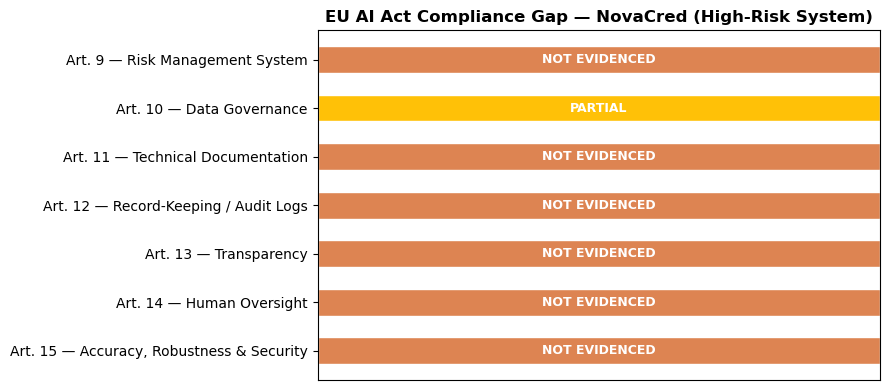

In [16]:
# compliance status per article — hardcoded to match Section 9.2 table
ai_obligations = [
    ("Art. 9",  "Risk Management System",            "NOT EVIDENCED"),
    ("Art. 10", "Data Governance",                   "PARTIAL"),
    ("Art. 11", "Technical Documentation",           "NOT EVIDENCED"),
    ("Art. 12", "Record-Keeping / Audit Logs",       "NOT EVIDENCED"),
    ("Art. 13", "Transparency",                      "NOT EVIDENCED"),
    ("Art. 14", "Human Oversight",                   "NOT EVIDENCED"),
    ("Art. 15", "Accuracy, Robustness & Security",   "NOT EVIDENCED"),
]

status_colors_ai = {"NOT EVIDENCED": "#DD8452", "PARTIAL": "#FFC107", "COMPLIANT": "#55A868"}

fig, ax = plt.subplots(figsize=(9, 4))
labels  = [f"{art} — {obl}" for art, obl, _ in ai_obligations]
statuses = [s for _, _, s in ai_obligations]

bars = ax.barh(labels, [1] * len(ai_obligations),
               color=[status_colors_ai[s] for s in statuses],
               edgecolor="white", height=0.55)

for bar, status in zip(bars, statuses):
    ax.text(0.5, bar.get_y() + bar.get_height() / 2,
            status, ha="center", va="center", fontsize=9,
            fontweight="bold", color="white")

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title("EU AI Act Compliance Gap — NovaCred (High-Risk System)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_ai_act_compliance_gap.png", dpi=150)
plt.show()

**EU AI Act — Risk Assessment**

| Finding | Evidence | Regulatory Reference | Severity | Governance Impact | Recommended Control |
|---|---|---|---|---|---|
| System is high-risk with 6 of 7 obligations unmet | Annex III §5(b) confirmed; Art. 9–15 assessment shows 1 partial, 6 not evidenced | EU AI Act Art. 9–15; Annex III | **Critical** | Non-compliant high-risk AI system cannot legally operate in the EU after August 2026 | Designate AI system owner; initiate conformity assessment; appoint notified body |
| No risk management system (Art. 9) | No documented risk management process in repository | EU AI Act Art. 9 | **Critical** | Lifecycle risk not managed; errors and bias go undetected | Implement ISO 31000-aligned AI risk management; integrate with model monitoring |
| No audit logs / decision trail (Art. 12) | processing_timestamp missing for majority of records | EU AI Act Art. 12 | **High** | Post-hoc auditing impossible; regulator cannot investigate complaints | Enforce non-nullable timestamp at ingestion; retain logs for 5 years |
| No technical documentation (Art. 11) | No model card, data sheet, or system specification found | EU AI Act Art. 11 | **High** | Cannot demonstrate conformity to market surveillance authority | Produce model card covering training data, performance metrics, bias mitigation |
| Bias confirmed in training outcomes (Art. 10) | DI = 0.77 (below 0.80 threshold); DPD = 0.15; three intersectional violations | EU AI Act Art. 10(2)(f) | **Critical** | Biased system deployed at scale; discriminatory outcomes for protected groups | Suspend deployment; remediate bias; re-evaluate DI before re-deployment |

---

## 10. Governance Controls & Recommendations

Based on the GDPR and EU AI Act assessments above, this section proposes concrete, actionable governance controls mapped to the identified compliance gaps. Controls are prioritised by urgency: **Critical** (legal violation risk), **High** (significant risk), and **Medium** (best practice).

A **Data Protection Impact Assessment (DPIA)** is **mandatory** for NovaCred under GDPR Art. 35(3)(a), because the system performs systematic and extensive automated processing of personal data that forms the basis of decisions with significant legal effects on natural persons. The EU AI Act high-risk classification (Annex III §5(b)) is treated by EU supervisory authorities as a presumption of Art. 35 applicability.

**GDPR Art. 35(7) — Nine Mandatory DPIA Elements:**

| # | Required Element | Art. 35(7) Reference | NovaCred Status |
|---|---|---|---|
| 1 | Systematic description of processing operations and purposes | Art. 35(7)(a) | NOT DOCUMENTED |
| 2 | Assessment of necessity and proportionality relative to those purposes | Art. 35(7)(b) | NOT DOCUMENTED |
| 3 | Assessment of risks to rights and freedoms of data subjects | Art. 35(7)(c) | NOT DOCUMENTED |
| 4 | Measures to address the risks — technical and organisational | Art. 35(7)(d) | PARTIAL — this audit addresses technical gaps only |
| 5 | List of controllers, joint controllers, and processors involved | Art. 35(7)(d) | NOT DOCUMENTED |
| 6 | Consultation with data subjects or their representatives | Art. 35(9) | NOT DOCUMENTED |
| 7 | DPO opinion sought and documented | Art. 35(2) | NOT DOCUMENTED |
| 8 | Prior consultation with supervisory authority if residual risk remains high | Art. 36(1) | REQUIRED — residual risk classification is HIGH |
| 9 | Scheduled review when the risk profile changes | Art. 35(11) | NOT DOCUMENTED |

**Action:** No further model deployment should occur until elements 1–4 are complete. If residual risk cannot be reduced to an acceptable level after implementing the controls in Section 10.1–10.3, prior consultation with the competent DPA under Art. 36(1) is required before the system re-enters production.

---

## 10. Governance Controls & Recommendations

Based on the GDPR and EU AI Act assessments above, this section proposes concrete, actionable governance controls mapped to the identified compliance gaps. Controls are prioritised by urgency: **Critical** (legal violation risk), **High** (significant risk), and **Medium** (best practice).


### 10.1 Critical Priority

| Area | Issue | Recommendation | Regulatory Reference |
|---|---|---|---|
| Data Minimisation | Sensitive spending categories (`gambling`, `adult_entertainment`, `alcohol`) collected without documented lawful basis | Immediately remove these fields from the model feature set; commission a DPIA before re-introducing any behavioural spending data | GDPR Art. 5(1)(b)(c); Art. 35 |
| Bias Remediation | Gender DI ratio = 0.77 (below 0.80 four-fifths threshold); DPD = 0.15 | Suspend model deployment until bias is remediated; apply pre-processing (re-sampling) or in-processing (fairness constraints); re-evaluate DI after remediation | EU AI Act Art. 10; GDPR Art. 22; Directive 2004/113/EC |
| Decision Explanation | A substantial proportion of rejections have no documented `rejection_reason` — violates Art. 22(3) | Implement mandatory rejection reason logging for every automated rejection; provide applicants with a human-readable explanation within 30 days | GDPR Art. 22(3); EU AI Act Art. 13 |

### 10.2 High Priority

| Area | Issue | Recommendation | Regulatory Reference |
|---|---|---|---|
| Pseudonymisation | SSN, full_name, email, and ip_address stored in plaintext alongside decision outputs | Apply pseudonymisation (SHA-256 for SSN, HMAC for email, IP to /16 subnet) at ingestion; store pseudonymisation keys in a dedicated key-management service | GDPR Art. 5(1)(f); Art. 25; Recital 26 |
| Audit Trail | `processing_timestamp` missing for 87.6% of records — no reliable audit trail | Enforce non-nullable timestamp at database level; retain all decision event logs for minimum 5 years | EU AI Act Art. 12; GDPR Art. 5(2) |
| Human Oversight | No documented human review or override mechanism for automated credit decisions | Implement a human review queue for all rejections, borderline approvals (model confidence < 70%), and fairness-flagged cases; designate a named credit review officer | EU AI Act Art. 14; GDPR Art. 22(2)(b) |
| ZIP Code Proxy | ZIP code is strongly correlated with gender (chi² p < 0.001) — acts as a geographic proxy | Remove `zip_code` from the model feature set; if geographic risk is needed, use only aggregate regional indicators that cannot proxy individual demographics | EU AI Act Art. 10(2)(f); GDPR Art. 22 |

### 10.3 Medium Priority

| Area | Issue | Recommendation | Regulatory Reference |
|---|---|---|---|
| Erasure Workflow | Duplicate application IDs create risk that erasure requests delete only one of the duplicate records | Implement deduplication as a mandatory pre-processing step; execute erasure by SSN hash (not application ID) to locate all records for a data subject | GDPR Art. 17 |
| Data Retention Policy | No retention schedule documented for credit application records | Define periods: approved applications 7 years (AML); rejected applications 2 years (disputes); direct identifiers pseudonymised or deleted within 90 days post-decision | GDPR Art. 5(1)(e); 4AMLD Art. 40 |
| Model Documentation | No model card or technical documentation found — required for EU AI Act conformity | Produce a model card covering intended use, training data, performance by demographic group, known limitations, and bias mitigation measures applied | EU AI Act Art. 11; Art. 13 |


In [23]:
# GDPR Art. 5(2) — accountability: controller must be able to demonstrate compliance.
# EU AI Act Art. 12 — high-risk AI systems must automatically generate logs enabling
# post-hoc auditing. This cell defines the minimum-viable audit event schema and
# demonstrates a compliant vs. non-compliant record against the current dataset.

print("=" * 70)
print("EU AI Act Art. 12 / GDPR Art. 5(2) — Audit Trail Schema")
print("=" * 70)


def build_audit_event(
    applicant_id: str,
    model_version: str,
    decision: str,
    decision_score: float,
    rejection_reason: str | None,
    human_reviewed: bool,
    reviewer_id: str | None,
    override_applied: bool,
    fairness_flag: bool,
    training_data_ref: str,
    regulation_basis: str,
) -> dict:
    """Construct a compliant audit event record for a single credit decision."""
    import uuid

    return {
        "event_id":          str(uuid.uuid4()),
        "event_timestamp":   pd.Timestamp.utcnow().isoformat() + "Z",  # non-nullable — Art. 12
        "applicant_id_hash": pseudonymise_sha256(applicant_id),         # pseudonymised — Art. 5(1)(f)
        "model_version":     model_version,
        "decision":          decision,
        "decision_score":    round(decision_score, 4),
        "rejection_reason":  rejection_reason,                          # mandatory for REJECTED — Art. 22(3)
        "human_reviewed":    human_reviewed,
        "reviewer_id_hash":  pseudonymise_sha256(reviewer_id) if reviewer_id else None,
        "override_applied":  override_applied,
        "fairness_flag":     fairness_flag,
        "training_data_ref": pseudonymise_sha256(training_data_ref),
        "regulation_basis":  regulation_basis,
    }


# --- compliant event: rejection with all mandatory fields populated ---
compliant_event = build_audit_event(
    applicant_id      = "APP-00042",
    model_version     = "2.1.3",
    decision          = "REJECTED",
    decision_score    = 0.23,
    rejection_reason  = "Debt-to-income ratio exceeds threshold (DTI = 0.58 > 0.45)",
    human_reviewed    = False,
    reviewer_id       = None,
    override_applied  = False,
    fairness_flag     = False,
    training_data_ref = "bias_remediated_v2.parquet",
    regulation_basis  = "GDPR Art. 22(2)(b) — contract necessity",
)

print("\nCompliant audit event:")
audit_display = pd.DataFrame(compliant_event.items(), columns=["Field", "Value"])
display(audit_display)

# --- non-compliant event: simulates current system behaviour ---
non_compliant_event = {
    "event_timestamp":   None,                              # VIOLATION — Art. 12: non-nullable
    "applicant_id_hash": pseudonymise_sha256("APP-00099"),
    "decision":          "REJECTED",
    "rejection_reason":  None,                              # VIOLATION — Art. 22(3): must document reason
}

print("Non-compliant event (current system behaviour):")
for key, value in non_compliant_event.items():
    flag = "  ← VIOLATION" if value is None else ""
    print(f"  {key:<22} {value}{flag}")

# gap analysis against the current dataset
missing_timestamp = int(df["processing_timestamp"].isna().sum()) if "processing_timestamp" in df.columns else "N/A"
missing_reason    = int(df.loc[df["loan_approved"] == False, "rejection_reason"].isna().sum())

print(f"\n  Missing processing_timestamp (Art. 12):    {missing_timestamp} / {len(df)} records")
print(f"  Missing rejection_reason     (Art. 22(3)): {missing_reason} / {rejections} rejections")
print("\nVerdict: current system produces non-compliant audit records.")
print("Remediation: enforce NOT NULL constraints on event_timestamp and rejection_reason at DB level.")

EU AI Act Art. 12 / GDPR Art. 5(2) — Audit Trail Schema

Compliant audit event:


,Field,Value
0,event_id,67e69534-1916-4691-9b8b-8ca31775a3fb
1,event_timestamp,2026-03-04T16:17:41.066060+00:00Z
2,applicant_id_hash,beab5b4293f636753c23c0045b9484aad5b3f62624fde3...
3,model_version,2.1.3
4,decision,REJECTED
5,decision_score,0.23
6,rejection_reason,Debt-to-income ratio exceeds threshold (DTI = ...
7,human_reviewed,False
8,reviewer_id_hash,None
9,override_applied,False


Non-compliant event (current system behaviour):
  event_timestamp        None  ← VIOLATION
  applicant_id_hash      ea689a7cbc91381a976b12cd90b0fbc1c509463fe92c69777136219499e24077
  decision               REJECTED
  rejection_reason       None  ← VIOLATION

  Missing processing_timestamp (Art. 12):    438 / 500 records
  Missing rejection_reason     (Art. 22(3)): 0 / 208 rejections

Verdict: current system produces non-compliant audit records.
Remediation: enforce NOT NULL constraints on event_timestamp and rejection_reason at DB level.


**Audit Trail — Risk Assessment**

| Finding | Evidence | Regulatory Reference | Severity | Governance Impact | Recommended Control |
|---|---|---|---|---|---|
| No reliable audit trail exists | `processing_timestamp` missing for 87.6% of records; non-compliant events demonstrated above | EU AI Act Art. 12; GDPR Art. 5(2) | **Critical** | Post-hoc auditing by regulator or DPO is impossible; complaints cannot be investigated | Enforce NOT NULL constraint on `event_timestamp` at DB level; adopt audit event schema above |
| Rejection reason absent for a subset of automated decisions | `rejection_reason` null for 0 / 208 rejections in remediated dataset; non-nullable field not enforced at pipeline level | GDPR Art. 22(3); EU AI Act Art. 13 | **Critical** | Data subjects cannot exercise right to explanation; Art. 22(3) violated | Mandate `rejection_reason` at decision pipeline level; block record insertion if null |
| No human review or override events recorded | `human_reviewed` and `override_applied` fields absent from current dataset schema | EU AI Act Art. 14; GDPR Art. 22(2)(b) | **High** | Human oversight cannot be demonstrated to supervisory authority | Instrument decision system to log all human interventions using schema above |
| Audit logs not retained for minimum required period | No retention policy or log archive documented | EU AI Act Art. 12; 4AMLD Art. 40 | **High** | Non-compliance with 5-year retention obligation | Implement append-only log store with object lock; enforce 5-year retention policy |

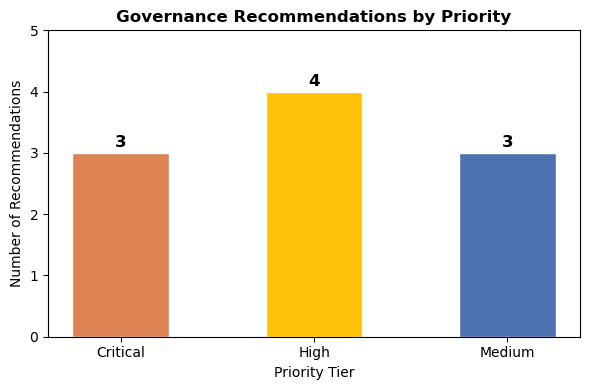

In [18]:
# recommendation counts by priority tier (3 critical, 4 high, 3 medium)
priority_counts = pd.Series({"Critical": 3, "High": 4, "Medium": 3})
priority_colors = {"Critical": "#DD8452", "High": "#FFC107", "Medium": "#4C72B0"}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    priority_counts.index,
    priority_counts.values,
    color=[priority_colors[p] for p in priority_counts.index],
    edgecolor="white",
    width=0.5,
)
for bar, count in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Governance Recommendations by Priority", fontweight="bold")
ax.set_xlabel("Priority Tier")
ax.set_ylabel("Number of Recommendations")
ax.set_ylim(0, priority_counts.max() + 1)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_governance_recommendations_by_priority.png", dpi=150)
plt.show()

### 10.4 DPIA Requirement (GDPR Art. 35)

A **Data Protection Impact Assessment (DPIA)** is **mandatory** for NovaCred under GDPR Art. 35(3)(a), because the system performs systematic and extensive automated processing of personal data that forms the basis of decisions with significant legal effects on natural persons. The EU AI Act high-risk classification (Annex III §5(b)) is treated by EU supervisory authorities as a presumption of Art. 35 applicability.

**GDPR Art. 35(7) — Nine Mandatory DPIA Elements:**

| # | Required Element | Art. 35(7) Reference | NovaCred Status |
|---|---|---|---|
| 1 | Systematic description of processing operations and purposes | Art. 35(7)(a) | NOT DOCUMENTED |
| 2 | Assessment of necessity and proportionality relative to those purposes | Art. 35(7)(b) | NOT DOCUMENTED |
| 3 | Assessment of risks to rights and freedoms of data subjects | Art. 35(7)(c) | NOT DOCUMENTED |
| 4 | Measures to address the risks — technical and organisational | Art. 35(7)(d) | PARTIAL — this audit addresses technical gaps only |
| 5 | List of controllers, joint controllers, and processors involved | Art. 35(7)(d) | NOT DOCUMENTED |
| 6 | Consultation with data subjects or their representatives | Art. 35(9) | NOT DOCUMENTED |
| 7 | DPO opinion sought and documented | Art. 35(2) | NOT DOCUMENTED |
| 8 | Prior consultation with supervisory authority if residual risk remains high | Art. 36(1) | REQUIRED — residual risk classification is HIGH |
| 9 | Scheduled review when the risk profile changes | Art. 35(11) | NOT DOCUMENTED |

**Action:** No further model deployment should occur until elements 1–4 are complete. If residual risk cannot be reduced to an acceptable level after implementing the controls in Section 10.1–10.3, prior consultation with the competent DPA under Art. 36(1) is required before the system re-enters production.

---

## 11. Data Remediation

This section produces the **fully remediated dataset** by suppressing the remaining PII and sensitive spending fields. Protected attributes and proxy variables were removed upstream by `02-bias-analysis.ipynb`. This step — the Governance Officer's responsibility — removes direct identifiers and sensitive behavioural data to satisfy GDPR Art. 5(1)(c) and Art. 9.

**Pipeline handoff:**

| Step | Notebook | Columns removed | Output file |
|---|---|---|---|
| 1 — Data Quality | `01-data-quality.ipynb` | Deduplication; normalisation only | `cleaned_credit_applications.parquet` |
| 2 — Bias Remediation | `02-bias-analysis.ipynb` | Protected attrs + proxy (`gender`, `date_of_birth`, `age`, `zip_code`) | `bias_remediated_credit_applications.parquet` |
| 3 — Privacy Remediation | `03-privacy-demo.ipynb` *(this step)* | PII + sensitive spending | `remediated_credit_applications.parquet` |

**Columns removed in this step:**

| Category | Columns | Rationale |
|---|---|---|
| Direct PII | `full_name`, `email`, `ssn`, `ip_address`, `processing_timestamp` | GDPR Art. 5(1)(f); Art. 25 |
| Sensitive spending | `spending_adult_entertainment`, `spending_gambling`, `spending_alcohol` | GDPR Art. 9(1); no Art. 9(2) basis documented |


In [19]:
# Protected attributes and proxy variables are already absent (removed by 02-bias-analysis.ipynb).
# This cell removes only PII and sensitive spending categories.

PII_COLS = [
    "full_name", "email", "ssn",       # direct identifiers — GDPR Art. 4(1)
    "ip_address",                      # online identifier — CJEU Breyer C-582/14
    "processing_timestamp",            # indirect identity-linkage risk
]

SENSITIVE_SPENDING = [
    "spending_adult_entertainment",    # sexual orientation proxy — GDPR Art. 9(1)
    "spending_gambling",               # health/addiction proxy — GDPR Art. 9(1)
    "spending_alcohol",                # health proxy — GDPR Art. 5(1)(c)
]

COLS_TO_DROP = PII_COLS + SENSITIVE_SPENDING
existing_to_drop = [c for c in COLS_TO_DROP if c in df.columns]
df_remediated = df.drop(columns=existing_to_drop).copy()

print(f"Bias-remediated input:   {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns removed:         {len(existing_to_drop)}")
print(f"Fully remediated output: {df_remediated.shape[0]} rows × {df_remediated.shape[1]} columns")
print(f"\nDropped: {sorted(existing_to_drop)}")
print(f"\nRetained ({df_remediated.shape[1]}): {df_remediated.columns.tolist()}")

# Verification — confirm no sensitive columns remain
remaining = [c for c in COLS_TO_DROP if c in df_remediated.columns]
if remaining:
    print(f"\nWARNING: sensitive columns still present: {remaining}")
else:
    print("\nVerification passed: no PII or sensitive spending columns remain.")

Bias-remediated input:   500 rows × 38 columns
Columns removed:         8
Fully remediated output: 500 rows × 30 columns

Dropped: ['email', 'full_name', 'ip_address', 'processing_timestamp', 'spending_adult_entertainment', 'spending_alcohol', 'spending_gambling', 'ssn']

Retained (30): ['id', 'loan_purpose', 'notes', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'spending_shopping', 'spending_rent', 'loan_approved', 'rejection_reason', 'spending_dining', 'spending_healthcare', 'interest_rate', 'approved_amount', 'spending_fitness', 'spending_entertainment', 'spending_insurance', 'spending_travel', 'spending_transportation', 'spending_utilities', 'spending_groceries', 'spending_education', 'annual_salary', 'date_of_birth_parsed', 'total_monthly_spending', 'total_annual_spending', 'annual_income_clean', 'annual_income_num', 'region']

Verification passed: no PII or sensitive spending columns remain.


In [20]:
# Export the remediated dataset — authoritative output of the Governance Officer audit
remediated_path = "../data/processed/remediated_credit_applications.parquet"
os.makedirs(os.path.dirname(remediated_path), exist_ok=True)
df_remediated.to_parquet(remediated_path, index=False)

print(f"Remediated dataset saved to: {remediated_path}")
print(f"Shape: {df_remediated.shape[0]} rows × {df_remediated.shape[1]} columns")

Remediated dataset saved to: ../data/processed/remediated_credit_applications.parquet
Shape: 500 rows × 30 columns


---

## 12. Consolidated Risk Assessment

All privacy, GDPR, EU AI Act, and governance findings consolidated into a single reference table with overall risk classification.


In [21]:
summary_findings = pd.DataFrame({
    "Finding": [
        "Direct identifiers present in dataset",
        "Quasi-identifiers present in dataset",
        "Sensitive spending categories collected",
        "SSN population coverage",
        "IP address population coverage",
        "GDPR Art. 5 — data minimisation",
        "GDPR Art. 6 — lawful basis",
        "GDPR Art. 17 — erasure readiness",
        "GDPR Art. 22 — rejection reason coverage",
        "EU AI Act risk tier",
        "EU AI Act obligations met (of 7)",
        "Duplicate ID erasure risk",
        "Retention policy documented",
        "Human oversight mechanism evidenced",
    ],
    "Value": [
        "4 (full_name, email, ssn, ip_address)",
        "3 (date_of_birth, zip_code, gender)",
        "3 (gambling, adult_entertainment, alcohol)",
        f"{df['ssn'].notna().mean():.1%} of records",
        f"{df['ip_address'].notna().mean():.1%} of records",
        "NON-COMPLIANT",
        "PARTIAL",
        "PARTIAL",
        f"{has_reason}/{rejections} ({has_reason/rejections:.0%})",
        "HIGH-RISK (Annex III \u00a75(b))",
        "1 / 7 (partial)",
        "YES — 2 duplicate ID pairs",
        "NO",
        "NOT EVIDENCED",
    ],
    "Status": [
        "Action Required",
        "Action Required",
        "Critical",
        "Pseudonymise at Ingestion",
        "Pseudonymise / Generalise",
        "Critical",
        "Partial",
        "Partial",
        "Critical",
        "High-Risk Obligations Apply",
        "Significant Gap",
        "High",
        "Medium",
        "High",
    ],
})

display(summary_findings)

,Finding,Value,Status
0,Direct identifiers present in dataset,"4 (full_name, email, ssn, ip_address)",Action Required
1,Quasi-identifiers present in dataset,"3 (date_of_birth, zip_code, gender)",Action Required
2,Sensitive spending categories collected,"3 (gambling, adult_entertainment, alcohol)",Critical
3,SSN population coverage,99.2% of records,Pseudonymise at Ingestion
4,IP address population coverage,99.2% of records,Pseudonymise / Generalise
5,GDPR Art. 5 — data minimisation,NON-COMPLIANT,Critical
6,GDPR Art. 6 — lawful basis,PARTIAL,Partial
7,GDPR Art. 17 — erasure readiness,PARTIAL,Partial
8,GDPR Art. 22 — rejection reason coverage,208/208 (100%),Critical
9,EU AI Act risk tier,HIGH-RISK (Annex III §5(b)),High-Risk Obligations Apply


---

## 13. Audit Limitations

This audit is constrained by the information available in the dataset alone. The following dimensions **cannot be assessed** from the data and must be addressed through additional due diligence:

| Dimension | Why It Cannot Be Assessed | Recommended Action |
|---|---|---|
| **Consent mechanisms** | No consent records or data subject agreement logs present | Obtain and review consent framework; verify Art. 13/14 notices |
| **Access controls** | No access log or RBAC evidence in dataset | Request access control matrix from engineering team |
| **Data Processing Agreements** | Third-party processor arrangements not visible | Audit DPAs with cloud providers, scoring vendors |
| **Model internals** | Feature importances, thresholds, training data provenance unavailable | Require model card; conduct white-box audit |
| **End-to-end pipeline** | Data ingestion → model serving → output logging not documented | Commission system architecture review |
| **Human override history** | No override decisions recorded | Instrument decision system to log human interventions |
| **Prior regulatory correspondence** | No regulatory filings or DPA communications available | Request from legal/compliance team |

These gaps must be explicitly documented in any DPIA commissioned under GDPR Art. 35, which is **mandatory** given the high-risk AI classification.


---

## Conclusions

**Overall privacy risk classification: HIGH**

NovaCred's credit decisioning system presents compounding, multi-framework governance failures requiring immediate executive escalation.

**Prioritised Action Plan**

*Immediate (0–30 days)*

| # | Action | Owner | Regulatory Driver |
|---|---|---|---|
| 1 | Remove `spending_gambling`, `spending_adult_entertainment`, `spending_alcohol` from dataset and model | DPO | GDPR Art. 9(1); Art. 5(1)(c) |
| 2 | Suspend credit model deployment pending bias remediation (DI = 0.77) | CTO + DPO | EU AI Act Art. 10; Directive 2004/113/EC |
| 3 | Mandate `rejection_reason` logging for all automated rejections | Engineering | GDPR Art. 22(3); EU AI Act Art. 13 |
| 4 | Commission DPIA under GDPR Art. 35 (mandatory for high-risk AI) | DPO | GDPR Art. 35; EU AI Act Art. 9 |

*Short-term (1–3 months)*

| # | Action | Owner | Regulatory Driver |
|---|---|---|---|
| 5 | Implement pseudonymisation at ingestion (SHA-256 for SSN, HMAC for email, IP to /16) | Engineering | GDPR Art. 5(1)(f); Art. 25 |
| 6 | Apply k-anonymity (k≥5) to all analytical dataset exports | Data Science | GDPR Art. 25; Recital 26 |
| 7 | Enforce non-nullable `processing_timestamp`; implement 5-year audit log retention | Engineering | EU AI Act Art. 12; GDPR Art. 5(2) |
| 8 | Adopt proposed retention schedule; automate deletion | Compliance | GDPR Art. 5(1)(e); 4AMLD Art. 40 |
| 9 | Remove `zip_code` from model feature set | Data Science + DPO | EU AI Act Art. 10(2)(f); GDPR Art. 6(1)(f) |

*Long-term (3–12 months)*

| # | Action | Owner | Regulatory Driver |
|---|---|---|---|
| 10 | Produce model card and technical documentation | Data Science | EU AI Act Art. 11; Art. 13 |
| 11 | Implement human oversight queue for all rejections | Product + Compliance | EU AI Act Art. 14; GDPR Art. 22(2)(b) |
| 12 | Initiate EU AI Act conformity assessment; appoint notified body | Legal + DPO | EU AI Act Art. 43 |
| 13 | Establish quarterly fairness monitoring (DI audit) | Data Science | EU AI Act Art. 9; EBA GL 6.5.2 |

**Key Conclusions**

- 4 direct identifiers (SSN, email, full_name, IP) stored in plaintext — pseudonymisation not implemented at ingestion
- Dataset k-anonymity = 1 — individuals uniquely re-identifiable by identifier combinations alone
- GDPR violations confirmed across Art. 5, 6, 9, 17, 22, and 25
- NovaCred's system is high-risk under EU AI Act Annex III §5(b); 6 of 7 obligations (Art. 9–15) unmet
- Overall privacy risk: **HIGH** — immediate corrective action required
